# 👋 AutoGluon Regression Tutorial for TimeSeries Predictor
Last updated: 08 Sep 2025

AutoGluon is an open-source, automated machine learning library in Python that simplifies building and deploying machine learning models. It provides a low-code interface for regression, classification, and time-series forecasting, ideal for researchers and citizen data scientists. AutoGluon automates data preprocessing, model selection, hyperparameter tuning, and ensemble creation, delivering high performance with minimal code.

This notebook analyzes prediction in the Chilwa Basin using the dataset from September 2025. It follows the workflow: **Setup** ➡️ **Data Analysis** ➡️ **Train Models** ➡️ **Analyze Model** ➡️ **Visualize Results** ➡️ **Save Outputs**. Results are formatted for a scientific paper.

**Dataset**: Chilwa Basin Dataset (starting from Jan 1, 1946, and extending into 2025, with future updates expected), containing environmental and health data. The dataset includes imputed `SatelliteAverageMinTemperature` (1946–2025) and new `Season` column for wet/dry seasonality.
**Objective**: Predict a user-specified target (e.g., `CholeraCasesTotal`, 2012–2022) using user-selected environmental or health features, incorporating seasonality via `Month` and `Season`.

# 🚧 Installation

Install AutoGluon, graphviz, and dependencies. Run this cell once per Colab session.


In [1]:
# Installation
!apt-get update -q
!apt-get install -y graphviz -q || { echo "Failed to install graphviz. Please ensure the 'dot' executable is available."; exit 1; }
!python -m pip install --upgrade pip -q
!python -m pip install autogluon -q
!python -m pip install pillow -q
!python -m pip install graphviz -q

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [5,526 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,

# 📚 Import Libraries

Import libraries for data processing, modeling, and visualization. The random seed ensures reproducibility.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor
import graphviz
from sklearn.tree import export_graphviz
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
from tabulate import tabulate
import shutil
import os
from PIL import Image
from sklearn.model_selection import KFold

from graphviz import Source  # Added import for Source

# Set random seed for reproducibility
np.random.seed(123)

# User Input: Specify Target Variable and Features

Specify the target variable to predict and the features to use in regression. Outputs are saved in a folder named after the target and date (`/content/Malawi/ChilwaRegression2025/{target}_{date}` and Google Drive equivalent).


Headers: Headers: ['Date', 'Month', 'Season',

'SatelliteAverageMinTemperature', 'SatelliteAverageMinTemperatureStandardizedAnomaly', 'SatelliteAverageMaxTemperature', 'AverageMeanTemperature', 'AverageMeanTemperatureAnomaly', 'AverageMeanTemperatureStandardizedAnomaly', 'ChancoMeanTemperature', 'ChingaleMeanTemperature', 'MakokaMeanTemperature', 'NaminjiwaMeanTemperature', 'NtajaMeanTemperature', 'ZombaRTCMeanTemperature', 'AverageMinTemperature', 'AverageMinTemperatureAnomaly', 'AverageMinTemperatureStandardizedAnomaly', 'ChancoMinTemperature', 'ChingaleMinTemperature', 'MakokaMinTemperature', 'NaminjiwaMinTemperature', 'NtajaMinTemperature', 'ZombaRTCMinTemperature', 'AverageMaxTemperature', 'AverageMaxTemperatureAnomaly', 'AverageMaxTemperatureStandardizedAnomaly', 'ChancoMaxTemperature', 'ChingaleMaxTemperature', 'MakokaMaxTemperature', 'NaminjiwaMaxTemperature', 'NtajaMaxTemperature', 'ZombaRTCMaxTemperature',

'SatelliteAverageRainfall', 'SatelliteAverageRainfallStandardizedAnomaly', 'AverageRainfall', 'RainfallAnomaly', 'StandardizedRainfallAnomaly', 'ChancoRainfall', 'ChingaleRainfall', 'MakokaRainfall', 'NaminjiwaRainfall', 'NtajaRainfall', 'ZombaRTCRainfall', 'ChancellorCollegeRainfall',

'ChimpeniRainfall', 'ReturnPeriod', 'ActualEvapotransp', 'ReferenceEvapoTransp', 'SoilMoisture', 'SPI1', 'SPI3', 'SPI6', 'SPI12', 'SPI24', 'SPI36', 'SPI48', 'SPI60', 'SPI72', 'PalmerDroughtSeverityIndex', 'Waterloggingkm2', 'LakeSurfaceAreakm2', 'LakeDepthm', 'NDVIAreakm2',

'CholeraCasesD1', 'CholeraCasesD2', 'CholeraCasesD3', 'CholeraCasesD4', 'CholeraCasesTotal', 'SchistosomiasisCasesD1', 'SchistosomiasisCasesD2', 'SchistosomiasisCasesD3', 'SchistosomiasisCasesD4', 'SchistosomiasisCasesTotal', 'MalariaCasesD1', 'MalariaCasesD2', 'MalariaCasesD3', 'MalariaCasesD4', 'MalariaCasesTotal', 'MosquitoNetsD1', 'MosquitoNetsD2', 'MosquitoNetsD3', 'MosquitoNetsD4', 'MosquitoNetsTotal', 'CholeraCases_AllDistricts', 'CholeraDeaths_AllDistricts', 'Malnutrition_LT5_NewCases_AllDistricts', 'Malnutrition_LT5_InpatientDeaths_AllDistricts', 'DiarrhoeaCases_Machinga', 'DiarrhoeaCases_Zomba', 'DiarrhoeaCases_Phalombe', 'DiarrhoeaCases_AllDistricts', 'SchistosomiasisCases_Machinga', 'SchistosomiasisCases_Zomba', 'SchistosomiasisCases_Phalombe', 'SchistosomiasisCases_AllDistricts', 'CholeraCasesDOH_Zomba', 'MalariaCasesDOH_Zomba', 'DiarrheaCasesDOH_Zomba', 'PopulationChilwaBasinMalawi', 'PopulationZomba', 'CerealProductionChilwaBasinMalawi', 'CerealProductionPerCapitaKgPerDay', 'TotalFishCatch', 'MaizeArea_HA_D1', 'MaizeProduction_MT_D1', 'RiceArea_HA_D1', 'RiceProduction_MT_D1', 'TobaccoArea_HA_D1', 'TobaccoProduction_MT_D1', 'UREA_T_D1', 'MaizeArea_HA_D2', 'MaizeProduction_MT_D2', 'RiceArea_HA_D2', 'RiceProduction_MT_D2', 'TobaccoArea_HA_D2', 'TobaccoProduction_MT_D2', 'UREA_T_D2', 'MaizeArea_HA_D4', 'MaizeProduction_MT_D4', 'RiceArea_HA_D4', 'RiceProduction_MT_D4', 'TobaccoArea_HA_D4', 'TobaccoProduction_MT_D4', 'UREA_T_D4', 'MaizeAreaTotal_HA', 'MaizeProductionTotal_MT', 'RiceAreaTotal_HA', 'RiceProductionTotal_MT', 'TobaccoAreaTotal_HA', 'TobaccoProductionTotal_MT', 'UREATotal_T']

In [3]:
import os
from datetime import datetime
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# User-specified target variable and features
target = 'SatelliteAverageRainfall'  # Changed to time-series target
features = ['ChimpeniRainfall', 'Month']  # Added Month, Season for seasonality , 'Season'

# Define date range
start_date = '1981-01-01'  # Adjusted for CholeraCasesTotal availability
end_date = '2021-12-01'

# Derive titles and filenames based on target
date_str = datetime.now().strftime('%Y%m%d')
prediction_title = f'{target.replace("Cases", " Cases")} Prediction'
output_dir = f'/content/Malawi/ChilwaRegression2025/{target}_TS_{date_str}'
drive_dir = f'/content/drive/My Drive/Malawi/ChilwaRegression2025/{target}_TS_{date_str}'
os.makedirs(output_dir, exist_ok=True)
os.makedirs(drive_dir, exist_ok=True)

# File paths for selected features
feature_importance_file = f'{output_dir}/feature_importance_{target}.png'
actual_vs_predicted_file = f'{output_dir}/actual_vs_predicted_{target}.png'
residuals_file = f'{output_dir}/residuals_{target}.png'
decision_tree_file = f'{output_dir}/decision_tree_{target}_highres.png'
missing_values_file = f'{output_dir}/missing_values_{target}.xlsx'
missing_values_plot = f'{output_dir}/missing_values_plot_{target}.jpg'
missing_values_heatmap = f'{output_dir}/missing_values_heatmap_{target}.jpg'
non_nan_rows_file = f'{output_dir}/non_nan_rows_{target}.xlsx'
start_end_dates_file = f'{output_dir}/start_end_dates_{target}.xlsx'
correlation_matrix_file = f'{output_dir}/pearson_correlation_matrix_{target}.xlsx'
correlation_plot = f'{output_dir}/pearson_correlation_matrix_plot_{target}.jpg'
results_file = f'{output_dir}/results_for_paper_{target}.txt'
tree_java_file = f'{output_dir}/prediction_tree_{target}.java'
linear_java_file = f'{output_dir}/prediction_linear_{target}.java'

# File paths for full dataset analysis
full_missing_values_file = f'{output_dir}/full_missing_values.xlsx'
full_missing_values_plot = f'{output_dir}/full_missing_values_plot.jpg'
full_missing_values_heatmap = f'{output_dir}/full_missing_values_heatmap.jpg'
full_non_nan_rows_file = f'{output_dir}/full_non_nan_rows.xlsx'
full_start_end_dates_file = f'{output_dir}/full_start_end_dates.xlsx'
full_correlation_matrix_file = f'{output_dir}/full_pearson_correlation_matrix.xlsx'
full_correlation_plot = f'{output_dir}/full_pearson_correlation_matrix_plot.jpg'

# Drive paths for selected features
drive_feature_importance_file = f'{drive_dir}/feature_importance_{target}.png'
drive_actual_vs_predicted_file = f'{drive_dir}/actual_vs_predicted_{target}.png'
drive_residuals_file = f'{drive_dir}/residuals_{target}.png'
drive_decision_tree_file = f'{drive_dir}/decision_tree_{target}_highres.png'
drive_missing_values_file = f'{drive_dir}/missing_values_{target}.xlsx'
drive_missing_values_plot = f'{drive_dir}/missing_values_plot_{target}.jpg'
drive_missing_values_heatmap = f'{drive_dir}/missing_values_heatmap_{target}.jpg'
drive_non_nan_rows_file = f'{drive_dir}/non_nan_rows_{target}.xlsx'
drive_start_end_dates_file = f'{drive_dir}/start_end_dates_{target}.xlsx'
drive_correlation_matrix_file = f'{drive_dir}/pearson_correlation_matrix_{target}.xlsx'
drive_correlation_plot = f'{drive_dir}/pearson_correlation_matrix_plot_{target}.jpg'
drive_results_file = f'{drive_dir}/results_for_paper_{target}.txt'
drive_tree_java_file = f'{drive_dir}/prediction_tree_{target}.java'
drive_linear_java_file = f'{drive_dir}/prediction_linear_{target}.java'

# Drive paths for full dataset analysis
drive_full_missing_values_file = f'{drive_dir}/full_missing_values.xlsx'
drive_full_missing_values_plot = f'{drive_dir}/full_missing_values_plot.jpg'
drive_full_missing_values_heatmap = f'{drive_dir}/full_missing_values_heatmap.jpg'
drive_full_non_nan_rows_file = f'{drive_dir}/full_non_nan_rows.xlsx'
drive_full_start_end_dates_file = f'{drive_dir}/full_start_end_dates.xlsx'
drive_full_correlation_matrix_file = f'{drive_dir}/full_pearson_correlation_matrix.xlsx'
drive_full_correlation_plot = f'{drive_dir}/full_pearson_correlation_matrix_plot.jpg'

Mounted at /content/drive


# 📊 Load and Preprocess Data
Load the Chilwa Basin dataset (ChilwaBasin_Dataset_09082025), filter by date range, and preprocess (handle NaNs, select features/target). Print headers to confirm correct loading.


In [4]:
# Load dataset
url = 'https://github.com/mtofighi/ChilwaBasin/blob/main/ChilwaBasin_DataAnalysis_032024/Dataset/ChilwaBasin_Dataset_09082025.xlsx?raw=true'
dataAll = pd.read_excel(url, sheet_name='ChilwaBasinMonthlyDataset')

# Print headers to confirm loading
headers = dataAll.columns.tolist()
print("Headers:", headers)

# Convert 'Date' column to datetime and set as index
dataAll['Date'] = pd.to_datetime(dataAll['Date'], errors='coerce')
dataAll = dataAll.dropna(subset=['Date'])
dataAll.set_index('Date', inplace=True)
dataAll = dataAll[~dataAll.index.duplicated(keep='first')].sort_index()

# Handle missing Month
if 'Month' in dataAll.columns:
    dataAll['Month'] = dataAll['Month'].fillna(dataAll.index.to_series().dt.month)
else:
    dataAll['Month'] = dataAll.index.to_series().dt.month

# Handle missing Season using rainfall thresholds
if 'Season' in dataAll.columns:
    # Define Season based on ChimpeniRainfall thresholds if missing
    def assign_season(rainfall):
        if pd.isna(rainfall):
            return np.nan
        elif rainfall > 100:
            return 1  # Wet
        elif rainfall < 20:
            return 3  # Dry
        else:
            return 2  # Transition
    dataAll['Season'] = dataAll['Season'].fillna(dataAll['ChimpeniRainfall'].apply(assign_season))
else:
    dataAll['Season'] = dataAll['ChimpeniRainfall'].apply(assign_season)

# Define date range
start_date = pd.to_datetime(start_date)
end_date = pd.to_datetime(end_date)
available_dates = dataAll.index
if start_date < available_dates.min():
    start_date = available_dates.min()
if end_date > available_dates.max():
    end_date = available_dates.max()

# Filter dataset and select user-specified features and target
sub_dataset = dataAll.loc[start_date:end_date, features + [target]]

# Handle NaNs for time-series
data = sub_dataset.loc[:, sub_dataset.isna().mean() < 0.7]
data = data.fillna(data.median(numeric_only=True))

# Verify target exists
if target not in data.columns:
    raise ValueError(f"Target '{target}' not found in dataset after preprocessing.")

# Prepare time-series dataframe
data = data.reset_index()  # Reset index to make 'Date' a column
data['item_id'] = 'ChilwaBasin'  # Add item_id column
ts_data = TimeSeriesDataFrame.from_data_frame(data, timestamp_column='Date')

# Display dataset info
print(f"\nTime-series dataset shape: {ts_data.shape}")
print(f"Columns: {list(ts_data.columns)}")

Headers: ['Date', 'Month', 'Season', 'SatelliteAverageMinTemperature', 'SatelliteAverageMinTemperatureStandardizedAnomaly', 'SatelliteAverageMaxTemperature', 'AverageMeanTemperature', 'AverageMeanTemperatureAnomaly', 'AverageMeanTemperatureStandardizedAnomaly', 'ChancoMeanTemperature', 'ChingaleMeanTemperature', 'MakokaMeanTemperature', 'NaminjiwaMeanTemperature', 'NtajaMeanTemperature', 'ZombaRTCMeanTemperature', 'AverageMinTemperature', 'AverageMinTemperatureAnomaly', 'AverageMinTemperatureStandardizedAnomaly', 'ChancoMinTemperature', 'ChingaleMinTemperature', 'MakokaMinTemperature', 'NaminjiwaMinTemperature', 'NtajaMinTemperature', 'ZombaRTCMinTemperature', 'AverageMaxTemperature', 'AverageMaxTemperatureAnomaly', 'AverageMaxTemperatureStandardizedAnomaly', 'ChancoMaxTemperature', 'ChingaleMaxTemperature', 'MakokaMaxTemperature', 'NaminjiwaMaxTemperature', 'NtajaMaxTemperature', 'ZombaRTCMaxTemperature', 'SatelliteAverageRainfall', 'SatelliteAverageRainfallStandardizedAnomaly', 'Aver

# 🔍 Data Analysis

Perform missing values analysis, heatmap visualization, start/end date analysis, and Pearson correlation analysis for both the selected features and the entire dataset. Save outputs to both Colab content and Google Drive.


In [5]:
# Function for missing values analysis
def missing_values_analysis(df, prefix, output_dir, drive_dir):
    # Ensure DateTimeIndex for start/end date analysis
    if prefix == 'Selected':
        df = df.set_index('timestamp')  # Set timestamp as index for Selected
    missing_values = df.isnull().sum()
    missing_percentage = (missing_values / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Values': missing_values, 'Missing Percentage': missing_percentage})
    missing_df = missing_df.sort_values(by='Missing Percentage', ascending=False)
    print(f"\n{prefix} Missing Values:")
    print(missing_df)
    missing_file = f'{output_dir}/{prefix.lower()}_missing_values.xlsx'
    missing_df.to_excel(missing_file)
    shutil.copy(missing_file, f'{drive_dir}/{prefix.lower()}_missing_values.xlsx')

    # Plot missing values
    plt.figure(figsize=(20, 6))
    plt.bar(missing_df.index, missing_df['Missing Percentage'])
    plt.xlabel('Variables')
    plt.ylabel('Missing Percentage (%)')
    plt.title(f'{prefix} Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True)
    plot_file = f'{output_dir}/{prefix.lower()}_missing_values_plot.jpg'
    plt.savefig(plot_file, dpi=300, bbox_inches='tight')
    shutil.copy(plot_file, f'{drive_dir}/{prefix.lower()}_missing_values_plot.jpg')
    plt.close()

    # Missing Values Heatmap
    plt.figure(figsize=(30, 10))
    if prefix == 'Selected':
        heatmap_data = pd.DataFrame(df[features + [target]])  # Only features and target for Selected
    else:
        heatmap_data = pd.DataFrame(df.drop(columns=['Date'], errors='ignore'))  # Exclude Date for Full
    sns.heatmap(heatmap_data.isnull().transpose(), cmap='viridis', cbar=False)
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.title(f'{prefix} Missing Values Heatmap')
    plt.xlabel('Date')
    plt.ylabel('Parameters')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray')
    heatmap_file = f'{output_dir}/{prefix.lower()}_missing_values_heatmap.jpg'
    plt.savefig(heatmap_file, dpi=300, bbox_inches='tight')
    shutil.copy(heatmap_file, f'{drive_dir}/{prefix.lower()}_missing_values_heatmap.jpg')
    plt.close()

    # Non-NaN Rows
    non_nan_rows = pd.DataFrame(df).dropna()  # Convert to pandas DataFrame before dropna
    print(f"\n{prefix} Rows with all values present:")
    print(non_nan_rows.head(5))
    non_nan_file = f'{output_dir}/{prefix.lower()}_non_nan_rows.xlsx'
    non_nan_rows.to_excel(non_nan_file)
    shutil.copy(non_nan_file, f'{drive_dir}/{prefix.lower()}_non_nan_rows.xlsx')

    # Start and End Dates Analysis
    start_dates = {}
    end_dates = {}
    months_data = {}
    years_data = {}
    for column in df.columns:
        not_missing_mask = df[column].notna()
        not_missing_data = df.loc[not_missing_mask]
        if not_missing_data.empty:
            continue
        start_dates[column] = not_missing_data.index[0]
        end_dates[column] = not_missing_data.index[-1]
        months_data[column] = (end_dates[column].year - start_dates[column].year) * 12 + (end_dates[column].month - start_dates[column].month) + 1
        years_data[column] = end_dates[column].year - start_dates[column].year + 1

    table_data = []
    for column, start_date in start_dates.items():
        end_date = end_dates[column]
        start_date_str = start_date.strftime("%Y-%m")
        end_date_str = end_date.strftime("%Y-%m")
        table_data.append([column, start_date_str, end_date_str, years_data[column], months_data[column]])
    table_data.sort(key=lambda x: df[x[0]].isnull().sum())
    table_headers = ["Column", "Start Date", "End Date", "Years Data", "Months Data"]
    print(f"\n{prefix} Start and End Dates:")
    print(tabulate(table_data, headers=table_headers, tablefmt="pipe"))
    start_end_df = pd.DataFrame(table_data, columns=table_headers)
    start_end_file = f'{output_dir}/{prefix.lower()}_start_end_dates.xlsx'
    start_end_df.to_excel(start_end_file, index=False)
    shutil.copy(start_end_file, f'{drive_dir}/{prefix.lower()}_start_end_dates.xlsx')

    # Pearson Correlation
    # if prefix == 'Selected':
    #     corr_data = pd.DataFrame(df[features + [target]])  # Only features and target for Selected
    # else:
    #     corr_data = pd.DataFrame(df.drop(columns=['Date'], errors='ignore'))  # Exclude Date for Full
    # correlation_matrix_pearson = pd.DataFrame(corr_data.select_dtypes(include=['float64', 'int64']).corr())  # Ensure pandas DataFrame
    # plt.figure(figsize=(30, 24))
    # sns.heatmap(correlation_matrix_pearson, annot=True if prefix == 'Selected' else False, cmap='coolwarm', fmt=".2f" if prefix == 'Selected' else None, annot_kws={"size": 24, 'weight': 'bold'} if prefix == 'Selected' else None, linewidths=0.5, cbar_kws={'label': 'Correlation'})
    # plt.title(f'{prefix} Pearson Correlation Matrix', fontweight='bold', fontsize=24)
    # if prefix == 'Selected':
    #     plt.xticks(rotation=90, ha='center', fontsize=24)
    #     plt.yticks(fontsize=24)
    # else:
    #     plt.xticks(rotation=90, ha='center', fontsize=10)
    #     plt.yticks(fontsize=10)
    # plt.tight_layout()
    # correlation_plot_file = f'{output_dir}/{prefix.lower()}_pearson_correlation_matrix_plot.jpg'
    # plt.savefig(correlation_plot_file, dpi=300, bbox_inches='tight')
    # shutil.copy(correlation_plot_file, f'{drive_dir}/{prefix.lower()}_pearson_correlation_matrix_plot.jpg')
    # plt.close()
    # correlation_file = f'{output_dir}/{prefix.lower()}_pearson_correlation_matrix.xlsx'
    # correlation_matrix_pearson.to_excel(correlation_file)
    # shutil.copy(correlation_file, f'{drive_dir}/{prefix.lower()}_pearson_correlation_matrix.xlsx')

    # Pearson Correlation
    if prefix == 'Selected':
        corr_data = pd.DataFrame(df[features + [target]])  # Only features and target for Selected
    else:
        corr_data = pd.DataFrame(df.drop(columns=['Date'], errors='ignore'))  # Exclude Date for Full

    correlation_matrix_pearson = pd.DataFrame(
        corr_data.select_dtypes(include=['float64', 'int64']).corr()
    )  # Ensure pandas DataFrame

    plt.figure(figsize=(30, 24))
    sns.heatmap(
        correlation_matrix_pearson,
        annot=True if prefix == 'Selected' else False,
        cmap='coolwarm',
        fmt=".2f" if prefix == 'Selected' else None,
        annot_kws={"size": 24, 'weight': 'bold'} if prefix == 'Selected' else None,
        linewidths=0.5,
        cbar_kws={
            'label': 'Correlation',
            'orientation': 'vertical'
        }
    )

    plt.title(f'{prefix} Pearson Correlation Matrix', fontweight='bold', fontsize=24)

    # Axis font customization
    if prefix == 'Selected':
        plt.xticks(rotation=90, ha='center', fontsize=24, fontweight='bold')
        plt.yticks(fontsize=24, fontweight='bold')
        plt.legend(
            loc='upper right',
            fontsize=20,
            title='Legend',
            title_fontsize=22,
            frameon=True
        )
    else:
        plt.xticks(rotation=90, ha='center', fontsize=10)
        plt.yticks(fontsize=10)
        plt.legend(
            loc='upper right',
            fontsize=10,
            title='Legend',
            title_fontsize=12,
            frameon=True
        )

    plt.tight_layout()

    # Save plot
    correlation_plot_file = f'{output_dir}/{prefix.lower()}_pearson_correlation_matrix_plot.jpg'
    plt.savefig(correlation_plot_file, dpi=300, bbox_inches='tight')
    shutil.copy(correlation_plot_file, f'{drive_dir}/{prefix.lower()}_pearson_correlation_matrix_plot.jpg')
    plt.close()

    # Save correlation matrix
    correlation_file = f'{output_dir}/{prefix.lower()}_pearson_correlation_matrix.xlsx'
    correlation_matrix_pearson.to_excel(correlation_file)
    shutil.copy(correlation_file, f'{drive_dir}/{prefix.lower()}_pearson_correlation_matrix.xlsx')


In [6]:
# Run for entire dataset
missing_values_analysis(dataAll, 'Full', output_dir, drive_dir)

# Run for selected features (convert TimeSeriesDataFrame to pandas with timestamp as column)
missing_values_analysis(ts_data.reset_index(), 'Selected', output_dir, drive_dir)


Full Missing Values:
                                Missing Values  Missing Percentage
MalariaCasesDOH_Zomba                      888           93.670886
DiarrheaCasesDOH_Zomba                     888           93.670886
PopulationZomba                            888           93.670886
CholeraCasesDOH_Zomba                      888           93.670886
SchistosomiasisCasesD3                     877           92.510549
...                                        ...                 ...
ChimpeniRainfall                            36            3.797468
Waterloggingkm2                             24            2.531646
ReturnPeriod                                24            2.531646
SatelliteAverageMinTemperature               0            0.000000
Month                                        0            0.000000

[131 rows x 2 columns]

Full Rows with all values present:
Empty DataFrame
Columns: [Month, Season, SatelliteAverageMinTemperature, SatelliteAverageMinTemperatureStandardize

/tmp/ipython-input-1191909571.py:149: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(



Selected Missing Values:
                          Missing Values  Missing Percentage
item_id                                0                 0.0
ChimpeniRainfall                       0                 0.0
Month                                  0                 0.0
SatelliteAverageRainfall               0                 0.0

Selected Rows with all values present:
                item_id  ChimpeniRainfall  Month  SatelliteAverageRainfall
timestamp                                                                 
1981-01-01  ChilwaBasin              92.5      1                     155.9
1981-02-01  ChilwaBasin             325.9      2                     263.1
1981-03-01  ChilwaBasin              94.5      3                     165.0
1981-04-01  ChilwaBasin              11.4      4                      43.8
1981-05-01  ChilwaBasin               0.0      5                      15.7

Selected Start and End Dates:
| Column                   | Start Date   | End Date   |   Years Data |  

/tmp/ipython-input-1191909571.py:139: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


# 🚀 Train AutoGluon Model

Train an AutoGluon TimeSeriesPredictor to predict the target using user-specified features and seasonality. The preset optimizes performance, and RMSE is used as the evaluation metric.

In [7]:
# Train AutoGluon TimeSeriesPredictor
predictor = TimeSeriesPredictor(
    path='autogluon_model',
    target=target,  # Use user-specified target
    known_covariates_names=features,  # Use user-specified features
    prediction_length=12,
    eval_metric='RMSE',
    freq='ME',  # Monthly frequency
    verbosity=2
).fit(
    train_data=ts_data,
    time_limit=600,  # Set to 600 for full training
    presets='best_quality',  # Use best quality preset
    hyperparameters={
        'ETS': {'seasonal_period': 12},
        'DeepAR': {'seasonal_period': 12},
        'SimpleFeedForward': {},
        'TemporalFusionTransformer': {'seasonal_period': 12}
    },
    num_val_windows=2,
    random_seed=123
)

# Save the predictor
print(f"Model saved in 'autogluon_model' directory.")

Beginning AutoGluon training... Time limit = 600s
AutoGluon will save models to '/content/autogluon_model'
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.11
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Sat Sep  6 09:54:41 UTC 2025
CPU Count:          2
GPU Count:          0
Memory Avail:       10.90 GB / 12.67 GB (86.0%)
Disk Space Avail:   62.36 GB / 107.72 GB (57.9%)
Setting presets to: best_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': RMSE,
 'freq': 'ME',
 'hyperparameters': {'DeepAR': {'seasonal_period': 12},
                     'ETS': {'seasonal_period': 12},
                     'SimpleFeedForward': {},
                     'TemporalFusionTransformer': {'seasonal_period': 12}},
 'known_covariates_names': ['ChimpeniRainfall', 'Month'],
 'num_val_windows': 2,
 'prediction_length': 12,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0

Model saved in 'autogluon_model' directory.


# 📈 Evaluate and Visualize Results

Evaluate the model with a leaderboard and feature importance. Generate visualizations (feature importance, actual vs. predicted, residuals, decision tree) for the paper, saved in both Colab content and Google Drive.


In [8]:
# Define prediction length
prediction_length = 12  # Matches original 12-month forecast horizon

# Model leaderboard
leaderboard = predictor.leaderboard(ts_data, silent=True)
print("\n## Model Leaderboard")
print("The following table presents the performance metrics for the models evaluated, sorted by test score (`score_test`):")
print(leaderboard[['model', 'score_test', 'score_val']].round(6).to_string(index=False))

# Feature importance
feature_importance = predictor.feature_importance(ts_data, time_limit=300)  # Increased time_limit
print("\n## Feature Importance")
print("The table below shows the importance of each feature, along with standard deviation and 99% confidence intervals:")
print(feature_importance[['importance', 'stdev', 'p99_low', 'p99_high']].round(6).to_string(index=True))

# Plot feature importance
plt.figure(figsize=(8, 5))
sns.barplot(x='importance', y=feature_importance.index, data=feature_importance,
            color='teal', xerr=feature_importance['stdev'].values)
plt.title(f'Feature Importance for {prediction_title}')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(feature_importance_file, dpi=300)
shutil.copy(feature_importance_file, drive_feature_importance_file)
plt.close()
print(f"Feature importance plot saved as '{feature_importance_file}' and copied to Google Drive.")

# Generate future covariates
last_timestamp = ts_data.index.get_level_values('timestamp').max()
future_timestamps = pd.date_range(start=last_timestamp + pd.offsets.MonthBegin(1),
                                 periods=prediction_length, freq='ME', normalize=True)
future_index = pd.MultiIndex.from_product([['ChilwaBasin'], future_timestamps],
                                         names=['item_id', 'timestamp'])
# Populate with future covariate values (example: repeat last row; replace with actual future data if available)
last_covariates = ts_data[features].iloc[-1:].reset_index(drop=True)
future_covariates_data = np.repeat(last_covariates.values, len(future_timestamps), axis=0)
future_covariates = TimeSeriesDataFrame(
    pd.DataFrame(future_covariates_data, columns=features, index=future_index)
)

# Verify the index alignment
print("Future covariates index:", future_covariates.index.levels[1].tolist())

# Generate predictions
predictions = predictor.predict(ts_data, known_covariates=future_covariates)
results = pd.DataFrame({
    'Actual': np.nan * np.ones(len(future_timestamps)),  # Placeholder for future actuals
    'Predicted': predictions['mean'].values
}, index=future_timestamps)

# Plot predicted values (no actuals for future horizon)
plt.figure(figsize=(8, 5))
plt.plot(results.index, results['Predicted'], label='Predicted', color='red')
plt.fill_between(results.index, predictions['0.1'].values, predictions['0.9'].values,
                 color='red', alpha=0.2, label='90% Prediction Interval')
plt.title(f'Predicted {prediction_title} with 90% Prediction Intervals')
plt.xlabel('Date')
plt.ylabel(target)
plt.legend()
plt.tight_layout()
actual_vs_predicted_interval_file = f'{output_dir}/actual_vs_predicted_interval_{target}.png'
drive_actual_vs_predicted_interval_file = f'{drive_dir}/actual_vs_predicted_interval_{target}.png'
plt.savefig(actual_vs_predicted_interval_file, dpi=300)
shutil.copy(actual_vs_predicted_interval_file, drive_actual_vs_predicted_interval_file)
plt.close()
print(f"Prediction plot saved as '{actual_vs_predicted_interval_file}' and copied to Google Drive.")


# Residual plots skipped as actual values for the future horizon are not available
print("Residual plots skipped as actual values for the future horizon are not available.")


# Prepare historical actuals
historical_actuals = ts_data[target].reset_index()
historical_actuals = historical_actuals.rename(columns={target: 'Actual'})
historical_actuals['Predicted'] = np.nan
historical_actuals.set_index('timestamp', inplace=True)

# Prepare future predictions
future_predictions_df = pd.DataFrame({
    'Actual': np.nan,
    'Predicted': predictions['mean'].values,
    'Lower': predictions['0.1'].values,
    'Upper': predictions['0.9'].values
}, index=future_timestamps)

# Combine historical and future data
full_series = pd.concat([historical_actuals, future_predictions_df])

# Plot actual and predicted values
plt.figure(figsize=(8, 5))
plt.plot(full_series.index, full_series['Actual'], label='Actual', color='blue')
plt.plot(full_series.index, full_series['Predicted'], label='Predicted', color='red')
plt.fill_between(full_series.index, full_series['Lower'], full_series['Upper'],
                 color='red', alpha=0.2, label='90% Prediction Interval')
plt.title(f'Actual and Predicted {prediction_title} with 90% Prediction Intervals')
plt.xlabel('Date')
plt.ylabel(target)
plt.legend()
plt.tight_layout()

# Save and copy to drive
actual_vs_predicted_interval_file = f'{output_dir}/actual_vs_predicted_interval_{target}_full.png'
drive_actual_vs_predicted_interval_file = f'{drive_dir}/actual_vs_predicted_interval_{target}_full.png'
plt.savefig(actual_vs_predicted_interval_file, dpi=300)
shutil.copy(actual_vs_predicted_interval_file, drive_actual_vs_predicted_interval_file)
plt.close()

print(f"Updated prediction plot saved as '{actual_vs_predicted_interval_file}' and copied to Google Drive.")


# Decision tree visualization
tree = DecisionTreeRegressor(max_depth=4, random_state=123)
tree.fit(ts_data[features].values, ts_data[target].values)
dot_data = export_graphviz(
    tree,
    feature_names=features,
    filled=True,
    rounded=True,
    special_characters=True
)
graph = Source(dot_data, format='png')
os.makedirs(os.path.dirname(decision_tree_file), exist_ok=True)
try:
    temp_file = os.path.join(output_dir, 'decision_tree_temp.png')
    graph.render(filename=temp_file[:-4], format='png', cleanup=True, engine='dot')
    try:
        with Image.open(temp_file) as img:
            img.save(decision_tree_file, dpi=(300, 300))
        os.remove(temp_file)
    except FileNotFoundError:
        print(f"Warning: Temporary file '{temp_file}' not found. Attempting direct save.")
        graph.render(filename=decision_tree_file[:-4], format='png', cleanup=True, engine='dot')
    shutil.copy(decision_tree_file, drive_decision_tree_file)
    print(f"Decision tree plot saved as '{decision_tree_file}' and copied to Google Drive.")
except Exception as e:
    print(f"Error rendering decision tree: {e}")
    print("Ensure graphviz is installed and the 'dot' executable is available.")
    print(f"Decision tree not saved to '{decision_tree_file}'.")

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=123)
tree_rmse_scores = []
lr_rmse_scores = []

for train_idx, test_idx in kf.split(ts_data):
    train_data, test_data = ts_data.iloc[train_idx], ts_data.iloc[test_idx]
    tree.fit(train_data[features].values, train_data[target].values)
    tree_pred = tree.predict(test_data[features].values)
    tree_rmse_scores.append(np.sqrt(mean_squared_error(test_data[target].values, tree_pred)))
    lr = LinearRegression()
    lr.fit(train_data[features].values, train_data[target].values)
    lr_pred = lr.predict(test_data[features].values)
    lr_rmse_scores.append(np.sqrt(mean_squared_error(test_data[target].values, lr_pred)))

print("\n## Cross-Validation Results")
print("The table below presents the mean RMSE and standard deviation for Decision Tree and Linear Regression models:")
cv_results = pd.DataFrame({
    'Model': ['Decision Tree (max_depth=4)', 'Linear Regression'],
    'Mean RMSE': [np.mean(tree_rmse_scores), np.mean(lr_rmse_scores)],
    'Std RMSE': [np.std(tree_rmse_scores), np.std(lr_rmse_scores)]
}).round(4)
print(cv_results.to_string(index=False))
cv_file = f'{output_dir}/cross_validation_results_{target}.csv'
drive_cv_file = f'{drive_dir}/cross_validation_results_{target}.csv'
cv_results.to_csv(cv_file, index=False)
shutil.copy(cv_file, drive_cv_file)
print(f"Cross-validation results saved as '{cv_file}' and copied to Google Drive.")

data with frequency 'MS' has been resampled to frequency 'ME'.
Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).
data with frequency 'MS' has been resampled to frequency 'ME'.



## Model Leaderboard
The following table presents the performance metrics for the models evaluated, sorted by test score (`score_test`):
                    model  score_test  score_val
TemporalFusionTransformer  -35.514958 -32.004263
         WeightedEnsemble  -35.767097 -31.951086
                      ETS  -48.270895 -46.197200
                   DeepAR  -52.802211 -46.477339
        SimpleFeedForward  -58.456886 -51.137903


Computing feature importance
Subsample_size 50 is larger than the number of items in the data and will be ignored



## Feature Importance
The table below shows the importance of each feature, along with standard deviation and 99% confidence intervals:
                  importance  stdev    p99_low   p99_high
ChimpeniRainfall   37.708842    0.0  37.708842  37.708842
Month              57.336988    0.0  57.336988  57.336988


data with frequency 'MS' has been resampled to frequency 'ME'.
Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


Feature importance plot saved as '/content/Malawi/ChilwaRegression2025/SatelliteAverageRainfall_TS_20250923/feature_importance_SatelliteAverageRainfall.png' and copied to Google Drive.
Future covariates index: [Timestamp('2022-01-31 00:00:00'), Timestamp('2022-02-28 00:00:00'), Timestamp('2022-03-31 00:00:00'), Timestamp('2022-04-30 00:00:00'), Timestamp('2022-05-31 00:00:00'), Timestamp('2022-06-30 00:00:00'), Timestamp('2022-07-31 00:00:00'), Timestamp('2022-08-31 00:00:00'), Timestamp('2022-09-30 00:00:00'), Timestamp('2022-10-31 00:00:00'), Timestamp('2022-11-30 00:00:00'), Timestamp('2022-12-31 00:00:00')]
Prediction plot saved as '/content/Malawi/ChilwaRegression2025/SatelliteAverageRainfall_TS_20250923/actual_vs_predicted_interval_SatelliteAverageRainfall.png' and copied to Google Drive.
Residual plots skipped as actual values for the future horizon are not available.
Updated prediction plot saved as '/content/Malawi/ChilwaRegression2025/SatelliteAverageRainfall_TS_20250923/actu

# Extract Best Model Formula

Extract a formula from a simplified decision tree or linear regression model approximating the best interpretable model, using AnyLogic variable names from the 'Categorized' sheet, saved as AnyLogic-compatible Java code.


In [9]:
# Load Categorized sheet for AnyLogic variable names
categorized = pd.read_excel(url, sheet_name='Categorized')
anylogic_var_map = dict(zip(categorized['Column_Header_in_the_Excel_Dataset'], categorized['Variable_Name_in_AnyLogic']))
anylogic_features = [anylogic_var_map.get(f, f) for f in features]
anylogic_target = anylogic_var_map.get(target, target)

# Ensure leaderboard is available
try:
    leaderboard
except NameError:
    leaderboard = predictor.leaderboard(ts_data, silent=True)
    print("\nGenerated Leaderboard:")
    print(leaderboard[['model', 'score_test', 'score_val']])

# Identify the best model
best_model_name = leaderboard.iloc[0]['model']
best_rmse = -leaderboard.iloc[0]['score_val']
print(f"\nBest Model: {best_model_name} (RMSE: {best_rmse:.4f})")

# Fit a simplified decision tree
tree = DecisionTreeRegressor(max_depth=4, random_state=123)
tree.fit(ts_data[features].values, ts_data[target].values)
tree_predictions = tree.predict(ts_data[features].values)
tree_rmse = np.sqrt(mean_squared_error(ts_data[target].values, tree_predictions))
tree_rmse_diff = tree_rmse - best_rmse
print(f"Decision Tree (max_depth=4) RMSE: {tree_rmse:.4f}, Difference from Best: {tree_rmse_diff:.4f} ({tree_rmse_diff/best_rmse*100:.2f}%)")

# Fit a linear regression model
lr = LinearRegression()
lr.fit(ts_data[features].values, ts_data[target].values)
lr_predictions = lr.predict(ts_data[features].values)
lr_rmse = np.sqrt(mean_squared_error(ts_data[target].values, lr_predictions))
lr_rmse_diff = lr_rmse - best_rmse
print(f"Linear Regression RMSE: {lr_rmse:.4f}, Difference from Best: {lr_rmse_diff:.4f} ({lr_rmse_diff/best_rmse*100:.2f}%)")

# Function to generate decision tree logic
def generate_tree_logic(tree, features, lang='java'):
    thresholds = tree.tree_.threshold
    feature_indices = tree.tree_.feature
    values = tree.tree_.value
    children_left = tree.tree_.children_left
    children_right = tree.tree_.children_right

    def recurse(node, depth, indent="    "):
        if children_left[node] == -1 and children_right[node] == -1:
            return f"{indent}{'return' if lang == 'java' else 'return'} {values[node][0][0]:.2f}{';' if lang == 'java' else ''}"
        feature = features[feature_indices[node]] if feature_indices[node] >= 0 else None
        if feature is None:
            return f"{indent}{'return' if lang == 'java' else 'return'} {values[node][0][0]:.2f}{';' if lang == 'java' else ''}"
        threshold = thresholds[node]
        code = f"{indent}if ({feature} <= {threshold:.2f}) {{\n"
        code += recurse(children_left[node], depth + 1, indent + "    ")
        code += f"\n{indent}}} else {{\n"
        code += recurse(children_right[node], depth + 1, indent + "    ")
        code += f"\n{indent}}}"
        return code

    return recurse(0, 0)

# Generate Java code for decision tree
java_code_tree = f"""
public class {anylogic_target}PredictionTree {{
    public static double predict({', '.join(f'double {f}' for f in anylogic_features)}) {{
        // Decision tree (max_depth=4) for {anylogic_target} prediction
        // Approximates WeightedEnsemble_L3
        double prediction = 0.0;
{generate_tree_logic(tree, anylogic_features, lang='java')}
        return prediction;
    }}
}}
"""

# Generate Python code for decision tree
python_code_tree = f"""
def predict_{anylogic_target}({', '.join(anylogic_features)}):
    # Decision tree (max_depth=4) for {anylogic_target} prediction
    # Approximates WeightedEnsemble_L3
{generate_tree_logic(tree, anylogic_features, lang='python')}
"""

# Generate Java code for linear regression
java_code_lr = f"""
public class {anylogic_target}PredictionLinear {{
    public static double predict({', '.join(f'double {f}' for f in anylogic_features)}) {{
        // Linear regression formula for {anylogic_target} prediction
        // Coefficients: {', '.join(f'{f}: {c:.2f}' for f, c in zip(anylogic_features, lr.coef_))}
        // Intercept: {lr.intercept_:.2f}
        double prediction = {lr.intercept_:.2f}
            {''.join(f' + {c:.2f} * {f}' for c, f in zip(lr.coef_, anylogic_features))};
        return prediction;
    }}
}}
"""

# Generate Python code for linear regression
python_code_lr = f"""
def predict_{anylogic_target}({', '.join(anylogic_features)}):
    # Linear regression formula for {anylogic_target} prediction
    # Coefficients: {', '.join(f'{f}: {c:.2f}' for f, c in zip(anylogic_features, lr.coef_))}
    # Intercept: {lr.intercept_:.2f}
    prediction = {lr.intercept_:.2f}
    {''.join(f' + {c:.2f} * {f}' for c, f in zip(lr.coef_, anylogic_features))}
    return prediction
"""

# Generate Excel formulas
excel_columns = [chr(65 + i) for i in range(len(features))]  # A, B, C, ...
excel_formula_lr = f"Excel Formula (Linear Regression): Assume features in columns A to {excel_columns[-1]} (row 2):\n= {lr.intercept_:.2f} + {' + '.join(f'{c:.2f} * {col}2' for c, col in zip(lr.coef_, excel_columns))}\nCopy down for other rows."

def generate_excel_tree_logic(tree, features):
    thresholds = tree.tree_.threshold
    feature_indices = tree.tree_.feature
    values = tree.tree_.value
    children_left = tree.tree_.children_left
    children_right = tree.tree_.children_right
    excel_columns = [chr(65 + i) for i in range(len(features))]

    def recurse(node, depth):
        if children_left[node] == -1 and children_right[node] == -1:
            return f"{values[node][0][0]:.2f}"
        feature = excel_columns[feature_indices[node]] if feature_indices[node] >= 0 else None
        if feature is None:
            return f"{values[node][0][0]:.2f}"
        threshold = thresholds[node]
        return f"IF({feature}2<={threshold:.2f},{recurse(children_left[node], depth + 1)},{recurse(children_right[node], depth + 1)})"

    return f"Excel Formula (Decision Tree): Assume features in columns A to {excel_columns[-1]} (row 2):\n= {recurse(0, 0)}\nCopy down for other rows."

excel_formula_tree = generate_excel_tree_logic(tree, features)

# Save Java code
with open(tree_java_file, 'w') as f:
    f.write(java_code_tree)
shutil.copy(tree_java_file, drive_tree_java_file)
print(f"\nDecision tree Java code saved as '{tree_java_file}' and copied to Google Drive.")

with open(linear_java_file, 'w') as f:
    f.write(java_code_lr)
shutil.copy(linear_java_file, drive_linear_java_file)
print(f"Linear regression Java code saved as '{linear_java_file}' and copied to Google Drive.")

# Save Python code
python_tree_file = f'{output_dir}/predict_{anylogic_target}_tree.py'
drive_python_tree_file = f'{drive_dir}/predict_{anylogic_target}_tree.py'
with open(python_tree_file, 'w') as f:
    f.write(python_code_tree)
shutil.copy(python_tree_file, drive_python_tree_file)
print(f"Decision tree Python code saved as '{python_tree_file}' and copied to Google Drive.")

python_linear_file = f'{output_dir}/predict_{anylogic_target}_linear.py'
drive_python_linear_file = f'{drive_dir}/predict_{anylogic_target}_linear.py'
with open(python_linear_file, 'w') as f:
    f.write(python_code_lr)
shutil.copy(python_linear_file, drive_python_linear_file)
print(f"Linear regression Python code saved as '{python_linear_file}' and copied to Google Drive.")

# Save Excel formulas
excel_file = f'{output_dir}/excel_formulas_{anylogic_target}.txt'
drive_excel_file = f'{drive_dir}/excel_formulas_{anylogic_target}.txt'
with open(excel_file, 'w') as f:
    f.write(f"{excel_formula_tree}\n\n{excel_formula_lr}")
shutil.copy(excel_file, drive_excel_file)
print(f"Excel formulas saved as '{excel_file}' and copied to Google Drive.")

# Print formulas for verification
print("\nJava Code for Decision Tree:")
print(java_code_tree)
print("\nJava Code for Linear Regression:")
print(java_code_lr)
print("\nPython Code for Decision Tree:")
print(python_code_tree)
print("\nPython Code for Linear Regression:")
print(python_code_lr)
print("\nExcel Formulas:")
print(excel_formula_tree)
print(excel_formula_lr)


Best Model: TemporalFusionTransformer (RMSE: 32.0043)
Decision Tree (max_depth=4) RMSE: 34.6235, Difference from Best: 2.6192 (8.18%)
Linear Regression RMSE: 49.1199, Difference from Best: 17.1157 (53.48%)

Decision tree Java code saved as '/content/Malawi/ChilwaRegression2025/SatelliteAverageRainfall_TS_20250923/prediction_tree_SatelliteAverageRainfall.java' and copied to Google Drive.
Linear regression Java code saved as '/content/Malawi/ChilwaRegression2025/SatelliteAverageRainfall_TS_20250923/prediction_linear_SatelliteAverageRainfall.java' and copied to Google Drive.
Decision tree Python code saved as '/content/Malawi/ChilwaRegression2025/SatelliteAverageRainfall_TS_20250923/predict_v_SatelliteAverageRainfall_tree.py' and copied to Google Drive.
Linear regression Python code saved as '/content/Malawi/ChilwaRegression2025/SatelliteAverageRainfall_TS_20250923/predict_v_SatelliteAverageRainfall_linear.py' and copied to Google Drive.
Excel formulas saved as '/content/Malawi/ChilwaReg

# 📝 Generate Output for Scientific Paper

Summarize results in a formatted text output for the paper, including dataset details, model performance, feature importance, and findings. Save to both Colab content and Google Drive.


In [ ]:
# Model leaderboard
leaderboard = predictor.leaderboard(ts_data, silent=True)
print("\n## Model Leaderboard")
print("The following table presents the performance metrics for the models evaluated, sorted by test score (`score_test`):")
print(leaderboard[['model', 'score_test', 'score_val']].round(6).to_string(index=False))

# Feature importance
feature_importance = predictor.feature_importance(ts_data, time_limit=300)  # Increased time_limit
print("\n## Feature Importance")
print("The table below shows the importance of each feature, along with standard deviation and 99% confidence intervals:")
print(feature_importance[['importance', 'stdev', 'p99_low', 'p99_high']].round(6).to_string(index=True))

# Plot feature importance
plt.figure(figsize=(8, 5))
sns.barplot(x='importance', y=feature_importance.index, data=feature_importance,
            color='teal', xerr=feature_importance['stdev'].values)
plt.title(f'Feature Importance for {prediction_title}')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(feature_importance_file, dpi=300)
shutil.copy(feature_importance_file, drive_feature_importance_file)
plt.close()
print(f"Feature importance plot saved as '{feature_importance_file}' and copied to Google Drive.")

# Generate future covariates
last_timestamp = ts_data.index.get_level_values('timestamp').max()
future_timestamps = pd.date_range(start='2023-01-31', periods=12, freq='ME', normalize=True)
future_index = pd.MultiIndex.from_product([['ChilwaBasin'], future_timestamps],
                                         names=['item_id', 'timestamp'])
# Populate with future covariate values (example: repeat last row; replace with actual future data if available)
last_covariates = ts_data[features].iloc[-1:].reset_index(drop=True)
future_covariates_data = np.repeat(last_covariates.values, len(future_timestamps), axis=0)
future_covariates = TimeSeriesDataFrame(
    pd.DataFrame(future_covariates_data, columns=features, index=future_index)
)

# Verify the index alignment
print("Future covariates index:", future_covariates.index.levels[1].tolist())

# Generate predictions
predictions = predictor.predict(ts_data, known_covariates=future_covariates)
results = pd.DataFrame({
    'Actual': np.nan * np.ones(len(future_timestamps)),  # Placeholder for future actuals
    'Predicted': predictions['mean'].values
}, index=future_timestamps)

# Plot predicted values (no actuals for future horizon)
plt.figure(figsize=(8, 5))
plt.plot(results.index, results['Predicted'], label='Predicted', color='red')
plt.fill_between(results.index, predictions['0.1'].values, predictions['0.9'].values,
                 color='red', alpha=0.2, label='90% Prediction Interval')
plt.title(f'Predicted {prediction_title} with 90% Prediction Intervals')
plt.xlabel('Date')
plt.ylabel(target)
plt.legend()
plt.tight_layout()
actual_vs_predicted_interval_file = f'{output_dir}/actual_vs_predicted_interval_{target}.png'
drive_actual_vs_predicted_interval_file = f'{drive_dir}/actual_vs_predicted_interval_{target}.png'
plt.savefig(actual_vs_predicted_interval_file, dpi=300)
shutil.copy(actual_vs_predicted_interval_file, drive_actual_vs_predicted_interval_file)
plt.close()
print(f"Prediction plot saved as '{actual_vs_predicted_interval_file}' and copied to Google Drive.")

# Residual plots skipped as actual values for the future horizon are not available
print("Residual plots skipped as actual values for the future horizon are not available.")

# Decision tree visualization
tree = DecisionTreeRegressor(max_depth=4, random_state=123)
tree.fit(ts_data[features].values, ts_data[target].values)
dot_data = export_graphviz(
    tree,
    feature_names=features,
    filled=True,
    rounded=True,
    special_characters=True
)
graph = Source(dot_data, format='png')
os.makedirs(os.path.dirname(decision_tree_file), exist_ok=True)
try:
    temp_file = os.path.join(output_dir, 'decision_tree_temp.png')
    graph.render(filename=temp_file[:-4], format='png', cleanup=True, engine='dot')
    try:
        with Image.open(temp_file) as img:
            img.save(decision_tree_file, dpi=(300, 300))
        os.remove(temp_file)
    except FileNotFoundError:
        print(f"Warning: Temporary file '{temp_file}' not found. Attempting direct save.")
        graph.render(filename=decision_tree_file[:-4], format='png', cleanup=True, engine='dot')
    shutil.copy(decision_tree_file, drive_decision_tree_file)
    print(f"Decision tree plot saved as '{decision_tree_file}' and copied to Google Drive.")
except Exception as e:
    print(f"Error rendering decision tree: {e}")
    print("Ensure graphviz is installed and the 'dot' executable is available.")
    print(f"Decision tree not saved to '{decision_tree_file}'.")

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=123)
tree_rmse_scores = []
lr_rmse_scores = []

for train_idx, test_idx in kf.split(ts_data):
    train_data, test_data = ts_data.iloc[train_idx], ts_data.iloc[test_idx]
    tree.fit(train_data[features].values, train_data[target].values)
    tree_pred = tree.predict(test_data[features].values)
    tree_rmse_scores.append(np.sqrt(mean_squared_error(test_data[target].values, tree_pred)))
    lr = LinearRegression()
    lr.fit(train_data[features].values, train_data[target].values)
    lr_pred = lr.predict(test_data[features].values)
    lr_rmse_scores.append(np.sqrt(mean_squared_error(test_data[target].values, lr_pred)))

print("\n## Cross-Validation Results")
print("The table below presents the mean RMSE and standard deviation for Decision Tree and Linear Regression models:")
cv_results = pd.DataFrame({
    'Model': ['Decision Tree (max_depth=4)', 'Linear Regression'],
    'Mean RMSE': [np.mean(tree_rmse_scores), np.mean(lr_rmse_scores)],
    'Std RMSE': [np.std(tree_rmse_scores), np.std(lr_rmse_scores)]
}).round(4)
print(cv_results.to_string(index=False))
cv_file = f'{output_dir}/cross_validation_results_{target}.csv'
drive_cv_file = f'{drive_dir}/cross_validation_results_{target}.csv'
cv_results.to_csv(cv_file, index=False)
shutil.copy(cv_file, drive_cv_file)
print(f"Cross-validation results saved as '{cv_file}' and copied to Google Drive.")

data with frequency 'MS' has been resampled to frequency 'ME'.
Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).
data with frequency 'MS' has been resampled to frequency 'ME'.
Computing feature importance
Subsample_size 50 is larger than the number of items in the data and will be ignored



## Model Leaderboard
The following table presents the performance metrics for the models evaluated, sorted by test score (`score_test`):
                    model  score_test  score_val
         WeightedEnsemble  -65.303617 -57.100853
                      ETS  -65.303617 -57.100853
                   DeepAR  -75.787564 -66.360403
        SimpleFeedForward  -92.444174 -77.343412
TemporalFusionTransformer -113.801969 -76.793226

## Feature Importance
The table below shows the importance of each feature, along with standard deviation and 99% confidence intervals:
                  importance  stdev  p99_low  p99_high
Month                    0.0    0.0      NaN       NaN
ChimpeniRainfall         0.0    0.0      NaN       NaN
Season                   0.0    0.0      NaN       NaN


data with frequency 'MS' has been resampled to frequency 'ME'.
Model not specified in predict, will default to the model with the best validation score: ETS


Feature importance plot saved as '/content/Malawi/ChilwaRegression2025/SatelliteAverageRainfall_20250909/feature_importance_SatelliteAverageRainfall.png' and copied to Google Drive.
Future covariates index: [Timestamp('2023-01-31 00:00:00'), Timestamp('2023-02-28 00:00:00'), Timestamp('2023-03-31 00:00:00'), Timestamp('2023-04-30 00:00:00'), Timestamp('2023-05-31 00:00:00'), Timestamp('2023-06-30 00:00:00'), Timestamp('2023-07-31 00:00:00'), Timestamp('2023-08-31 00:00:00'), Timestamp('2023-09-30 00:00:00'), Timestamp('2023-10-31 00:00:00'), Timestamp('2023-11-30 00:00:00'), Timestamp('2023-12-31 00:00:00')]
Prediction plot saved as '/content/Malawi/ChilwaRegression2025/SatelliteAverageRainfall_20250909/actual_vs_predicted_interval_SatelliteAverageRainfall.png' and copied to Google Drive.
Residual plots skipped as actual values for the future horizon are not available.
Decision tree plot saved as '/content/Malawi/ChilwaRegression2025/SatelliteAverageRainfall_20250909/decision_tree_Sate

# 💾 Save Model

The model is automatically saved in the 'autogluon_model' directory. Outputs are saved in both Colab content and Google Drive for manual copying or direct access.


In [ ]:
print(f"Model saved in 'autogluon_model' directory.")
print(f"All outputs saved in '{output_dir}' and '{drive_dir}'.")

Model saved in 'autogluon_model' directory.
All outputs saved in '/content/Malawi/ChilwaRegression2025/CholeraCasesTotal_20250908' and '/content/drive/My Drive/Malawi/ChilwaRegression2025/CholeraCasesTotal_20250908'.


# 💾 Impute the missing values of Tempreture (1946-1969)

The model is


In [ ]:
data = dataAll
satellite_mean = data.loc['1981-01-01':'2024-12-31']['SatelliteAverageMinTemperature'].mean()
print(f"Mean SatelliteAverageMinTemperature (1981–2024): {satellite_mean:.2f}")

Mean SatelliteAverageMinTemperature (1981–2024): 17.08


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
from sklearn.metrics import mean_squared_error
from glob import glob

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# File paths
url = 'https://github.com/mtofighi/ChilwaBasin/blob/main/ChilwaBasin_DataAnalysis_032024/Dataset/ChilwaBasin_Dataset_09032025.xlsx?raw=true'
output_dir = '/content/Malawi/ChilwaRegression2025/SatelliteAverageMinTemperature_20250905'
drive_dir = '/content/drive/My Drive/Malawi/ChilwaRegression2025/SatelliteAverageMinTemperature_20250905'


gee_folder = '/content/drive/My Drive/Malawi/GEE_Folder'

era5_file = f'{gee_folder}/ChilwaBasin_ERA5Land_Temperature_Daily_1950_2025.csv'
imputed_file = f'{output_dir}/imputed_SatelliteAverageMinTemperature_1946_2025.csv'
drive_imputed_file = f'{drive_dir}/imputed_SatelliteAverageMinTemperature_1946_2025.csv'
plot_file = f'{output_dir}/imputed_plot.png'
drive_plot_file = f'{drive_dir}/imputed_plot.png'
updated_dataset_file = f'{output_dir}/ChilwaBasin_Dataset_Updated_1946_2025.xlsx'
drive_updated_dataset_file = f'{drive_dir}/ChilwaBasin_Dataset_Updated_1946_2025.xlsx'

# Define temperature column
temp_column = 'SatelliteAverageMinTemperature'

# Create directories
os.makedirs(output_dir, exist_ok=True)
os.makedirs(drive_dir, exist_ok=True)
print(f'Output directories created: {output_dir}, {drive_dir}')

# Load dataset directly from Excel
print('Loading dataset from Excel...')
try:
    dataAll = pd.read_excel(url, sheet_name='ChilwaBasinMonthlyDataset')
except Exception as e:
    print(f'Error loading Excel file: {e}')
    raise
print(f'Available columns in dataAll: {list(dataAll.columns)}')

# Verify dataset
if 'Date' not in dataAll.columns:
    print('Error: "Date" column not found in dataAll.')
    raise KeyError('Missing Date column in dataAll.')
if temp_column not in dataAll.columns:
    print(f'Error: "{temp_column}" column not found in dataAll. Available columns: {list(dataAll.columns)}')
    raise KeyError(f'Missing {temp_column} column in dataAll.')
if not pd.api.types.is_datetime64_any_dtype(dataAll['Date']):
    print('Converting "Date" column to datetime...')
    dataAll['Date'] = pd.to_datetime(dataAll['Date'], errors='coerce')
    if dataAll['Date'].isna().any():
        print('Error: Invalid dates in Date column after conversion.')
        raise ValueError('Invalid dates in dataAll.')
dataAll = dataAll.set_index('Date').sort_index()
if dataAll.index.has_duplicates:
    print('Warning: Duplicate dates found in dataAll. Keeping first occurrence.')
    dataAll = dataAll[~dataAll.index.duplicated(keep='first')]
print(f'Original dataset loaded. Shape: {dataAll.shape}')
print(f'Original data range: {dataAll.index.min()} to {dataAll.index.max()}')
missing_original = dataAll[temp_column].isna().sum()
print(f'Missing {temp_column} values in original data: {missing_original}')
if missing_original > 0:
    print(f'Warning: {missing_original} missing values detected in original {temp_column}.')

# Load ERA5-Land data
print('Loading ERA5-Land data...')
if os.path.exists(era5_file):
    era5_data = pd.read_csv(era5_file, parse_dates=['Date'], date_format='%m/%d/%Y')
else:
    print(f'Warning: {era5_file} not found. Attempting to load yearly CSVs...')
    era5_files = glob(f'{gee_folder}/ChilwaBasin_ERA5Land_Temperature_Daily_*.csv')
    if not era5_files:
        print(f'Error: No ERA5-Land CSV files found in {gee_folder}.')
        raise FileNotFoundError
    era5_data = pd.concat([pd.read_csv(f, parse_dates=['Date'], date_format='%m/%d/%Y') for f in era5_files])
try:
    era5_data.set_index('Date', inplace=True)
except pd.errors.ParserError:
    print('Error: Invalid date format in ERA5-Land CSV. Expected MM/dd/YYYY.')
    raise
era5_data = era5_data.sort_index()
if era5_data.index.has_duplicates:
    print('Warning: Duplicate dates found in ERA5-Land data. Keeping first occurrence.')
    era5_data = era5_data[~era5_data.index.duplicated(keep='first')]
if 'SatelliteAverageMinTemperature' not in era5_data.columns:
    print('Error: ERA5-Land CSV must contain "SatelliteAverageMinTemperature" column.')
    raise KeyError('Missing SatelliteAverageMinTemperature in ERA5-Land data.')
missing_era5 = era5_data['SatelliteAverageMinTemperature'].isna().sum()
print(f'ERA5-Land data loaded. Shape: {era5_data.shape}')
print(f'ERA5-Land data range: {era5_data.index.min()} to {era5_data.index.max()}')
print(f'Missing SatelliteAverageMinTemperature values in ERA5-Land data: {missing_era5}')
if missing_era5 > 0:
    print(f'Warning: {missing_era5} missing values detected in ERA5-Land SatelliteAverageMinTemperature.')

# Check date consistency
expected_dates = pd.date_range(start='1950-01-01', end='2025-08-05', freq='D')
if not era5_data.index.isin(expected_dates).all():
    print('Warning: ERA5-Land data contains unexpected dates.')
if era5_data.index.min() > pd.Timestamp('1950-01-01') or era5_data.index.max() < pd.Timestamp('2025-08-05'):
    print('Warning: ERA5-Land data does not cover full range (1950-01-01 to 2025-08-05).')

# Aggregate ERA5-Land to monthly data
print('Aggregating ERA5-Land data to monthly...')
era5_monthly = era5_data['SatelliteAverageMinTemperature'].resample('ME').mean()
print(f'ERA5-Land monthly data created. Shape: {era5_monthly.shape}')

# Create full monthly date range (1946–2025)
full_dates = pd.date_range(start='1946-01-31', end='2025-08-31', freq='ME')
imputed_data = pd.DataFrame(index=full_dates)

# Merge ERA5-Land monthly data
imputed_data['SatelliteAverageMinTemperature'] = era5_monthly
print(f'Merged ERA5-Land data for 1950–2025.')

# Preserve original TerraClimate data (1981–2024) where available
overlap_period = imputed_data.loc['1981-01-01':'2024-12-31'].index.intersection(dataAll.index)
imputed_data.loc[overlap_period, 'SatelliteAverageMinTemperature'] = dataAll.loc[overlap_period, temp_column]
print(f'Preserved original TerraClimate data for 1981–2024 where available.')

# Interpolate for 1946–1969
print('Interpolating SatelliteAverageMinTemperature for 1946–1969...')
imputed_data['SatelliteAverageMinTemperature'] = imputed_data['SatelliteAverageMinTemperature'].interpolate(method='linear', limit_direction='both')
missing_imputed = imputed_data['SatelliteAverageMinTemperature'].isna().sum()
print('Interpolation completed.')
if missing_imputed > 0:
    print(f'Error: {missing_imputed} missing values remain after interpolation.')
    raise ValueError('Interpolation failed to fill all missing values.')
print(f'Imputed data range: {imputed_data.index.min()} to {imputed_data.index.max()}')

# Save imputed temperature data
imputed_data.to_csv(imputed_file)
shutil.copy(imputed_file, drive_imputed_file)
print(f'Imputed SatelliteAverageMinTemperature (1946–2025) saved as {imputed_file} and copied to Google Drive.')

# Update original dataset
print('Updating original dataset...')
updated_data = dataAll.copy()
updated_data['SatelliteAverageMinTemperature'] = imputed_data['SatelliteAverageMinTemperature'].reindex(updated_data.index, method='ffill')
missing_updated = updated_data['SatelliteAverageMinTemperature'].isna().sum()
print('Merged imputed SatelliteAverageMinTemperature.')
if missing_updated > 0:
    print(f'Warning: {missing_updated} missing values in updated dataset SatelliteAverageMinTemperature.')
updated_data.to_excel(updated_dataset_file)
shutil.copy(updated_dataset_file, drive_updated_dataset_file)
print(f'Updated dataset saved as {updated_dataset_file} and copied to Google Drive.')

# Validate imputation on 1981–2024
print('Validating imputation on 1981–2024...')
validation_data = dataAll.loc['1981-01-01':'2024-12-31', temp_column]
imputed_validation = imputed_data.loc['1981-01-01':'2024-12-31', 'SatelliteAverageMinTemperature']
common_dates = validation_data.index.intersection(imputed_validation.index)
validation_data = validation_data.loc[common_dates].dropna()
imputed_validation = imputed_validation.loc[common_dates].dropna()
if len(validation_data) > 0:
    rmse = np.sqrt(mean_squared_error(validation_data, imputed_validation))
    print(f'Validation RMSE (1981–2024): {rmse:.2f}°C')
    if rmse > 2.0:
        print('Warning: High RMSE (>2.0°C) suggests potential misalignment. Check ERA5-Land data or calibration.')
else:
    print('Warning: No overlapping data for validation (1981–2024).')

# Visualize imputed data
print('Generating imputation plot...')
plt.figure(figsize=(10, 6))
plt.plot(imputed_data.loc['1946-01-01':'1969-12-31'].index,
         imputed_data.loc['1946-01-01':'1969-12-31']['SatelliteAverageMinTemperature'],
         label='Imputed (1946–1969)', color='red')
plt.plot(imputed_data.loc['1970-01-01':'2025-08-31'].index,
         imputed_data.loc['1970-01-01':'2025-08-31']['SatelliteAverageMinTemperature'],
         label='ERA5-Land/TerraClimate (1970–2025)', color='blue')
plt.plot(dataAll.loc['1981-01-01':'2024-12-31'].index,
         dataAll.loc['1981-01-01':'2024-12-31', temp_column],
         label='Original TerraClimate (1981–2024)', color='green', alpha=0.5)
plt.title('Imputed SatelliteAverageMinTemperature (1946–2025)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.savefig(plot_file, dpi=300)
shutil.copy(plot_file, drive_plot_file)
plt.close()
print(f'Imputation plot saved as {plot_file} and copied to Google Drive.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output directories created: /content/Malawi/ChilwaRegression2025/SatelliteAverageMinTemperature_20250905, /content/drive/My Drive/Malawi/ChilwaRegression2025/SatelliteAverageMinTemperature_20250905
Loading dataset from Excel...
Available columns in dataAll: ['Date', 'Month', 'SatelliteAverageMinTemperature', 'SatelliteAverageMinTemperatureStandardizedAnomaly', 'SatelliteAverageMaxTemperature', 'AverageMeanTemperature', 'AverageMeanTemperatureAnomaly', 'AverageMeanTemperatureStandardizedAnomaly', 'ChancoMeanTemperature', 'ChingaleMeanTemperature', 'MakokaMeanTemperature', 'NaminjiwaMeanTemperature', 'NtajaMeanTemperature', 'ZombaRTCMeanTemperature', 'AverageMinTemperature', 'AverageMinTemperatureAnomaly', 'AverageMinTemperatureStandardizedAnomaly', 'ChancoMinTemperature', 'ChingaleMinTemperature', 'MakokaMinTemperature', 'NaminjiwaMinTemperature', 'NtajaMinTem

**Season**

Date column is already in datetime format.
Dataset loaded. Shape: (948, 3)
Data range: 1946-01-01 00:00:00 to 2024-12-01 00:00:00
Missing values:
Month                             24
ChimpeniRainfall                  36
SatelliteAverageMinTemperature    36
dtype: int64
Complete data (1946–2023) shape: (936, 3)
Monthly mean values:
    Month  ChimpeniRainfall  SatelliteAverageMinTemperature
0     1.0        266.860526                       19.193421
1     2.0        219.942105                       18.935526
2     3.0        179.192105                       18.543421
3     4.0         52.622368                       17.640789
4     5.0         12.740789                       16.063158
5     6.0          3.809211                       14.200000
6     7.0          3.144737                       13.134211
7     8.0          2.860526                       13.223684
8     9.0          4.263158                       15.305263
9    10.0         20.397368                       18.214474
10   11

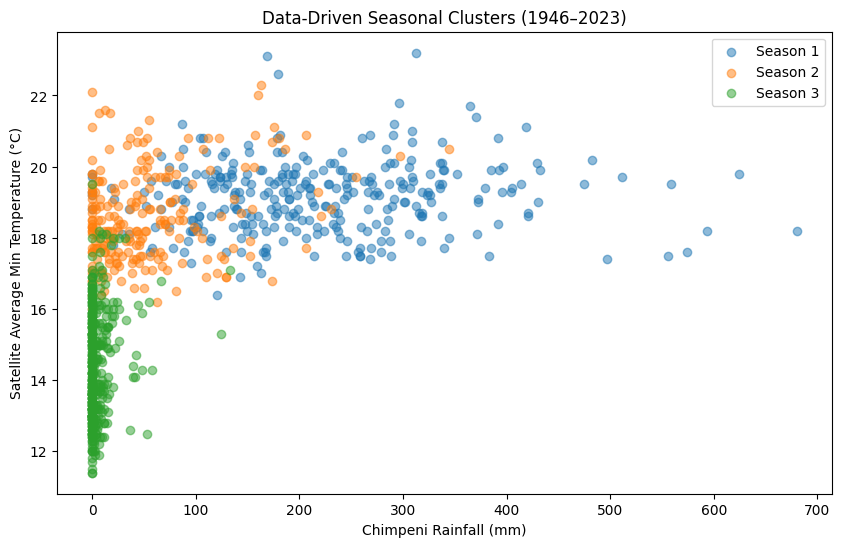

Numerical Season column (Wet=1, Dry=3, Transition=2) added and saved to ChilwaBasin_Dataset_09052025-Season_Updated.xlsx


In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load Excel file
url = 'https://github.com/mtofighi/ChilwaBasin/blob/main/ChilwaBasin_DataAnalysis_032024/Dataset/ChilwaBasin_Dataset_09052025_Season.xlsx?raw=true'
data = pd.read_excel(url, sheet_name='Sheet1')

# Check and convert Date column
if not pd.api.types.is_datetime64_any_dtype(data['Date']):
    print('Converting Date column from numeric to datetime...')
    data['Date'] = pd.to_datetime(data['Date'], origin='1899-12-30', unit='D', errors='coerce')
else:
    print('Date column is already in datetime format.')

# Preprocess data
data = data.dropna(subset=['Date'])
data = data.set_index('Date').sort_index()

# Verify data
print(f'Dataset loaded. Shape: {data.shape}')
print(f'Data range: {data.index.min()} to {data.index.max()}')
print(f'Missing values:\n{data.isna().sum()}')

# Filter complete data (1946–2023) to exclude missing rainfall in 2024–2025
data_complete = data.loc['1946-01-01':'2023-12-31'].copy()
print(f'Complete data (1946–2023) shape: {data_complete.shape}')

# Aggregate by Month to compute mean rainfall and temperature
monthly_means = data_complete.groupby('Month')[['ChimpeniRainfall', 'SatelliteAverageMinTemperature']].mean().reset_index()
print('Monthly mean values:')
print(monthly_means)

# Prepare data for clustering
X = monthly_means[['ChimpeniRainfall', 'SatelliteAverageMinTemperature']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-means clustering (k=3 for Wet, Dry, Transition)
kmeans = KMeans(n_clusters=3, random_state=42)
monthly_means['Cluster'] = kmeans.fit_predict(X_scaled)

# Map clusters to numerical season labels based on rainfall
cluster_means = monthly_means.groupby('Cluster')[['ChimpeniRainfall', 'SatelliteAverageMinTemperature']].mean()
print('Cluster means:')
print(cluster_means)

# Sort clusters by rainfall to assign labels
cluster_means_sorted = cluster_means.sort_values('ChimpeniRainfall', ascending=False)
season_labels = {}
season_labels[cluster_means_sorted.index[0]] = 1  # Wet (highest rainfall)
season_labels[cluster_means_sorted.index[1]] = 2  # Transition (middle rainfall)
season_labels[cluster_means_sorted.index[2]] = 3  # Dry (lowest rainfall)

monthly_means['Season'] = monthly_means['Cluster'].map(season_labels)

# Map Season to full dataset based on Month
data['Season'] = data['Month'].map(monthly_means.set_index('Month')['Season'])

# Verify Season distribution
print('Season distribution:')
print(data['Season'].value_counts())

# Plot seasonal patterns
plt.figure(figsize=(10, 6))
for season in data['Season'].unique():
    if pd.notna(season):
        season_data = data[data['Season'] == season]
        plt.scatter(season_data['ChimpeniRainfall'], season_data['SatelliteAverageMinTemperature'], label=f'Season {int(season)}', alpha=0.5)
plt.xlabel('Chimpeni Rainfall (mm)')
plt.ylabel('Satellite Average Min Temperature (°C)')
plt.title('Data-Driven Seasonal Clusters (1946–2023)')
plt.legend()
plt.savefig('seasonal_clusters.png', dpi=300)
plt.show()

# Save updated Excel
output_file = 'ChilwaBasin_Dataset_09052025-Season_Updated.xlsx'
data.to_excel(output_file, index=True)
print(f'Numerical Season column (Wet=1, Dry=3, Transition=2) added and saved to {output_file}')